<div align="center">

# Toward Sustainable Artificial Intelligence
## Energy-Efficient Machine Learning Models: Global Data Center Analysis

| | |
|---|---|
| **Author** | Nino Miljkovic |
| **Course** | DSCI 6800 - AI and Machine Learning |
| **Instructor** | Dr. Yi Zhu |
| **Date** | October 2025 |

</div>

---

## Abstract

This notebook investigates the global landscape of data center infrastructure and its
relationship with renewable energy adoption. Using a country-level dataset from Kaggle,
we apply exploratory data analysis, unsupervised clustering (K-Means + PCA), and
supervised regression (XGBoost / Ridge) to understand what drives sustainable practices
in data centers worldwide.

**Key questions addressed:**
1. Which countries lead in data center capacity and power?
2. How do infrastructure scale, internet penetration, and growth rates correlate with
   renewable energy usage?
3. Can we predict a country's renewable adoption from operational and connectivity signals?
4. What happens to renewable adoption if internet penetration increases by 10 % globally?


---
## 1  Dataset

| | |
|---|---|
| **Source** | [Kaggle – Global Data Center Dataset](https://www.kaggle.com/datasets/rockyt07/data-center-dataset) |
| **Coverage** | Country-level, as of 2025 |
| **Key columns** | `total_data_centers`, `power_capacity_MW_total`, `floor_space_sqft_total`, `average_renewable_energy_usage_percent`, `internet_penetration_percent`, `growth_rate_of_data_centers_percent_per_year`, and more |

Place `Global_Data_Center.xlsx` in the **same directory** as this notebook before running.


## 2  Environment Setup

In [1]:
# ── Standard library ──────────────────────────────────────────────────────────
import os
import re
import warnings
warnings.filterwarnings("ignore")

# ── Data wrangling ─────────────────────────────────────────────────────────────
import numpy  as np
import pandas as pd
import openpyxl  # required by pd.read_excel for .xlsx files

# ── Visualisation ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Machine learning ───────────────────────────────────────────────────────────
from sklearn.cluster         import KMeans
from sklearn.decomposition   import PCA
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition   import LatentDirichletAllocation
from sklearn.impute          import SimpleImputer
from sklearn.inspection      import PartialDependenceDisplay
from sklearn.linear_model    import RidgeCV
from sklearn.metrics         import r2_score, mean_squared_error
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline        import Pipeline
from sklearn.preprocessing   import StandardScaler
from xgboost                 import XGBRegressor

# ── Reproducibility ────────────────────────────────────────────────────────────
RANDOM_STATE = 42
os.environ["OMP_NUM_THREADS"] = "1"   # prevents KMeans memory-leak warning on Windows

# ── Plot aesthetics ────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (9, 5)})

print("All packages loaded successfully.")


All packages loaded successfully.


## 3  Load Data

In [2]:
DATA_FILE = "Global_Data_Center.xlsx"

dataset = pd.read_excel(DATA_FILE)

print(f"Shape: {dataset.shape[0]:,} rows × {dataset.shape[1]} columns")
dataset.head()


Shape: 191 rows × 19 columns


,country,total_data_centers,hyperscale_data_centers,colocation_data_centers,floor_space_sqft_total,power_capacity_MW_total,average_renewable_energy_usage_percent,tier_distribution,key_operators,cloud_provider,internet_penetration_percent,avg_latency_to_global_hubs_ms,number_of_fiber_connections,growth_rate_of_data_centers_percent_per_year,cooling_technologies_common,regulatory_challenges_or_limits,disaster_recovery_sites_common,green_dc_initiatives_description,source_of_data
0,United States,5426,300,"~2,000+","~3,552,000,000","~12,000+",~27%,"I:5%, II:15%, III:60%, IV:20%","Equinix, Digital Realty, CoreSite, AWS","AWS:Yes, GCP:Yes, Azure:Yes, Oracle:Yes",0.92,40,60+,0.12,"Air, Liquid, Immersion","Power grid strain in VA, moratoriums in some s...","Yes, especially for finance/health","Solar, wind PPA, immersion cooling, LEED","Statista, Brightlio, IEA, CBRE"
1,Germany,529,50,~200,"~350,000,000","~2,000+",40%+,"II:10%, III:70%, IV:20%","Equinix, Digital Realty, e-shelter","AWS:Yes, GCP:Yes, Azure:Yes, Oracle:Yes",0.92,50,30+,0.08,"Air, Indirect Evap.","Power caps in Frankfurt, strict emissions","Yes, especially for finance","Wind, solar, carbon-neutral push","Statista, CBRE, IEA"
2,United Kingdom,523,30,~150,"~200,000,000","~1,000+",0.45,"II:15%, III:70%, IV:15%","Equinix, Telehouse, Virtus","AWS:Yes, GCP:Yes, Azure:Yes, Oracle:Yes",0.96,40,25+,0.07,"Air, Free Cooling",Power grid constraints in London,"Yes, especially for finance","Wind, solar, carbon-neutral targets","Statista, CBRE, IEA"
3,China,449,100,"~1,000+","~500,000,000","~8,000+",0.25,"II:20%, III:60%, IV:20%","China Unicom, Tencent, Alibaba, GDS","AWS:Yes, GCP:No, Azure:Yes, Oracle:Yes",0.76,75,40+,0.15,"Air, Liquid",Power rationing in some provinces,"Yes, for government/finance","Hydro, wind, solar, green finance","Statista, CBRE, IEA"
4,France,322,20,~110,"~120,000,000",~700,40%+,"II:20%, III:70%, IV:10%","Equinix, Interxion, Data4","AWS:Yes, GCP:Yes, Azure:Yes, Oracle:Yes",0.91,50,20+,0.06,"Air, Liquid",Power grid constraints in Paris,"Yes, for finance/health","Wind, solar, PUE targets","Statista, CBRE, IEA"


In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 19 columns):
 #   Column                                        Non-Null Count  Dtype 
---  ------                                        --------------  ----- 
 0   country                                       191 non-null    str   
 1   total_data_centers                            191 non-null    int64 
 2   hyperscale_data_centers                       191 non-null    int64 
 3   colocation_data_centers                       191 non-null    object
 4   floor_space_sqft_total                        191 non-null    object
 5   power_capacity_MW_total                       191 non-null    object
 6   average_renewable_energy_usage_percent        191 non-null    object
 7   tier_distribution                             179 non-null    str   
 8   key_operators                                 170 non-null    str   
 9   cloud_provider                                149 non-null    str   
 10  internet_pene

> **Observation:** Several columns contain non-numeric markers (`~`, `+`, `Unknown`) and
> inconsistent formatting. The next section standardises all numeric columns before analysis.


## 4  Preprocessing

In [4]:
# ── Helper: extract the maximum numeric value from a messy string ─────────────
def to_numeric_max(s):
    """Return the largest number embedded in a string, or NaN."""
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    if s.lower() in {"unknown", "n/a", "na", "-", "--", ""}:
        return np.nan
    s = s.replace("~", "").replace("+", "")
    nums = re.findall(r"-?\d+(?:,\d{3})*(?:\.\d+)?", s)
    if not nums:
        return np.nan
    return max(float(x.replace(",", "")) for x in nums)


# ── Clean integer columns ──────────────────────────────────────────────────────
int_cols = [
    "hyperscale_data_centers",
    "colocation_data_centers",
    "floor_space_sqft_total",
    "power_capacity_MW_total",
]
for col in int_cols:
    dataset[col] = (
        dataset[col]
        .apply(to_numeric_max)
        .round()
        .astype("Int64")   # nullable integer — preserves missing values
    )

print("Integer columns cleaned:")
dataset[int_cols].info()
dataset[int_cols].head()


Integer columns cleaned:
<class 'pandas.DataFrame'>
RangeIndex: 191 entries, 0 to 190
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   hyperscale_data_centers  191 non-null    Int64
 1   colocation_data_centers  191 non-null    Int64
 2   floor_space_sqft_total   184 non-null    Int64
 3   power_capacity_MW_total  165 non-null    Int64
dtypes: Int64(4)
memory usage: 6.8 KB


,hyperscale_data_centers,colocation_data_centers,floor_space_sqft_total,power_capacity_MW_total
0,300,2000,3552000000,12000
1,50,200,350000000,2000
2,30,150,200000000,1000
3,100,1000,500000000,8000
4,20,110,120000000,700


In [5]:
# ── Helper: extract the maximum percentage value from a messy string ──────────
def clean_percent_max(s):
    """
    Normalise a messy percent string to a float in [0, 100].

    Rules applied in order:
    1. Null / unknown markers → NaN
    2. Strip cosmetic characters (~, +)
    3. If any number is followed by %, take the maximum of those
    4. Otherwise, if all values are in [0, 1], scale × 100
    5. Ignore year-like numbers (≥ 150); keep the largest remaining
    """
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    if s.lower() in {"unknown", "n/a", "na", "-", "--", ""}:
        return np.nan

    s = s.replace("~", "").replace("+", "")

    # Numbers directly tied to a % sign
    pct_nums = re.findall(r"(-?\d+(?:,\d{3})*(?:\.\d+)?)\s*%", s)
    if pct_nums:
        vals = [abs(float(x.replace(",", ""))) for x in pct_nums]
        val  = max(vals)
        return val * 100.0 if 0 <= val <= 1 else val

    # Fallback: any number
    nums = re.findall(r"-?\d+(?:,\d{3})*(?:\.\d+)?", s)
    if not nums:
        return np.nan
    vals = [float(x.replace(",", "")) for x in nums]

    frac_vals = [v for v in vals if 0 <= v <= 1]
    if frac_vals and not any(v > 1 for v in vals):
        return max(frac_vals) * 100.0

    smalls = [v for v in vals if v < 150]
    return max(smalls) if smalls else max(vals)


# ── Apply to all percentage columns ───────────────────────────────────────────
pct_cols = [
    "average_renewable_energy_usage_percent",
    "internet_penetration_percent",
    "growth_rate_of_data_centers_percent_per_year",
]
for col in pct_cols:
    dataset[col] = (
        dataset[col]
        .apply(clean_percent_max)
        .round(2)
        .astype("Float64")
    )

print("Percentage columns cleaned:")
dataset[pct_cols].describe()


Percentage columns cleaned:


,average_renewable_energy_usage_percent,internet_penetration_percent,growth_rate_of_data_centers_percent_per_year
count,148.0,190.0,174.0
mean,50.905405,74.646316,9.80931
std,32.460709,28.008345,13.099445
min,0.0,2.0,-0.4
25%,25.0,55.4,4.1775
50%,46.5,82.0,7.625
75%,81.025,92.0,11.075
max,100.0,150.0,100.0


In [6]:
# ── Summary statistics after cleaning ─────────────────────────────────────────
dataset.describe()


,total_data_centers,hyperscale_data_centers,colocation_data_centers,floor_space_sqft_total,power_capacity_MW_total,average_renewable_energy_usage_percent,internet_penetration_percent,growth_rate_of_data_centers_percent_per_year
count,191.000000,191.0,191.0,184.0,165.0,148.0,190.0,174.0
mean,60.685864,3.575916,30.445026,28063467.554348,275.30303,50.905405,74.646316,9.80931
std,398.980748,23.347337,162.185098,265678858.530075,1158.560884,32.460709,28.008345,13.099445
min,0.000000,0.0,0.0,0.0,0.0,0.0,2.0,-0.4
25%,1.500000,0.0,1.0,8000.0,1.0,25.0,55.4,4.1775
50%,4.000000,0.0,4.0,30000.0,15.0,46.5,82.0,7.625
75%,20.000000,0.0,17.5,305000.0,145.0,81.025,92.0,11.075
max,5426.000000,300.0,2000.0,3552000000.0,12000.0,100.0,150.0,100.0


## 5  Exploratory Data Analysis

### 5.1  Top 10 Countries by Data Center Count

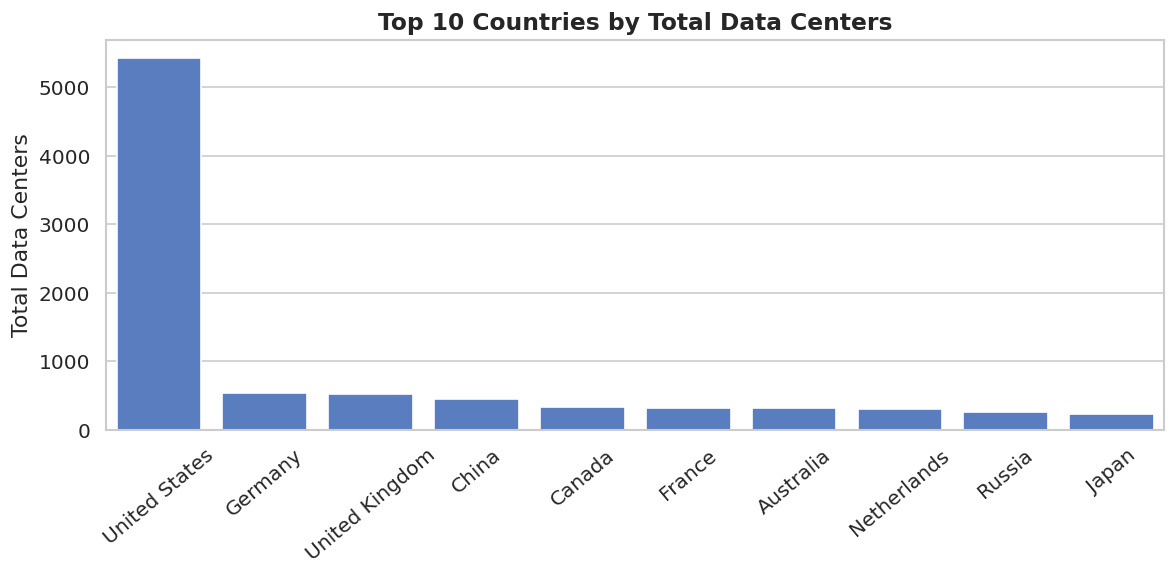

,country,total_data_centers
0,United States,5426
1,Germany,529
2,United Kingdom,523
3,China,449
4,Canada,336
5,France,322
6,Australia,314
7,Netherlands,298
8,Russia,251
9,Japan,222


In [7]:
top10 = (
    dataset[["country", "total_data_centers"]]
    .sort_values("total_data_centers", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top10, x="country", y="total_data_centers", ax=ax)
ax.set_title("Top 10 Countries by Total Data Centers", fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Total Data Centers")
ax.tick_params(axis="x", rotation=40)
plt.tight_layout()
plt.show()

top10


> **Finding:** The United States leads by a large margin, followed by Germany, the
> United Kingdom, and China. These four countries account for the majority of global
> data center capacity.


### 5.2  Correlation Analysis (Spearman)

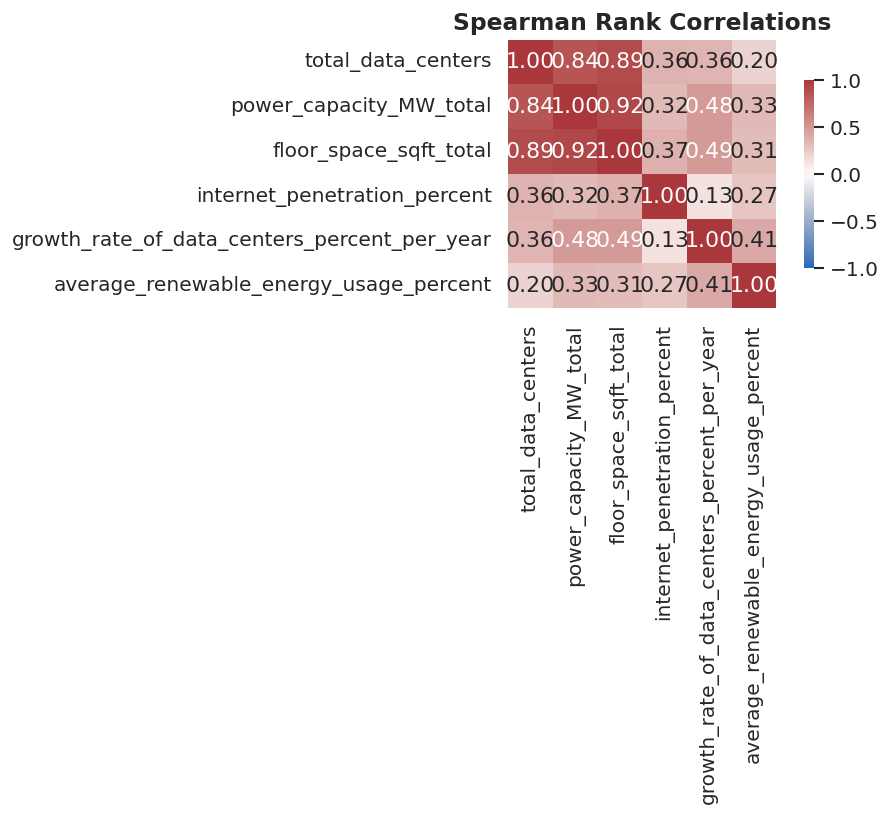

In [8]:
corr_cols = [
    "total_data_centers",
    "power_capacity_MW_total",
    "floor_space_sqft_total",
    "internet_penetration_percent",
    "growth_rate_of_data_centers_percent_per_year",
    "average_renewable_energy_usage_percent",
]

corr = dataset[corr_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, vmin=-1, vmax=1, cmap="vlag",
    annot=True, fmt=".2f", square=True,
    cbar_kws={"shrink": 0.7}, ax=ax
)
ax.set_title("Spearman Rank Correlations", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


**Strongest positive correlations:**
- `floor_space_sqft_total` ↔ `power_capacity_MW_total` ≈ 0.92
- `total_data_centers` ↔ `floor_space_sqft_total` ≈ 0.89
- `total_data_centers` ↔ `power_capacity_MW_total` ≈ 0.84

**Weakest correlations:**
- `internet_penetration_percent` ↔ `growth_rate_of_data_centers_percent_per_year` ≈ 0.13
- `total_data_centers` ↔ `average_renewable_energy_usage_percent` ≈ 0.20

No negative correlations were observed.


### 5.3  Scale Relationship: Data Centers vs. Power Capacity

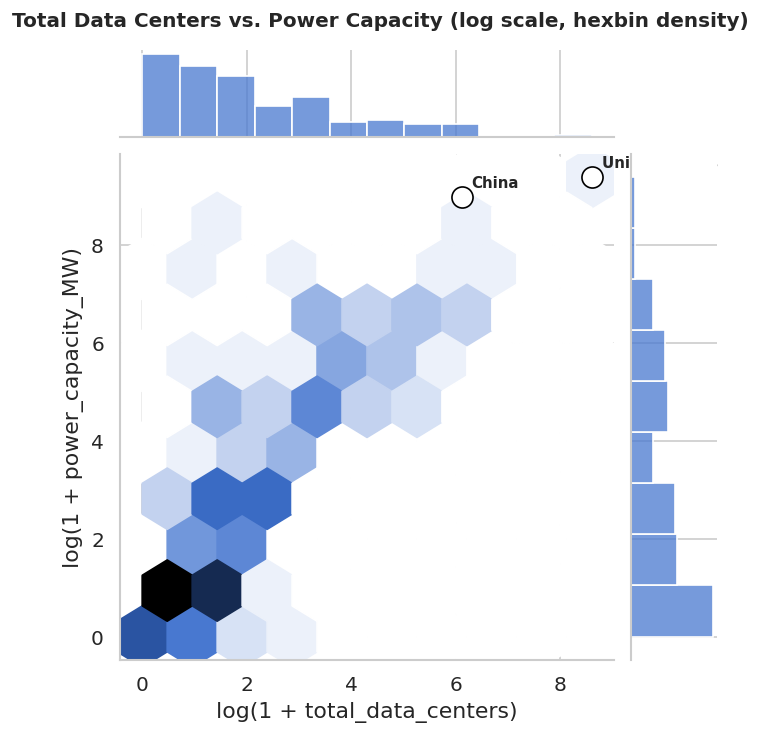

In [9]:
df = dataset.dropna(subset=["total_data_centers", "power_capacity_MW_total"]).copy()
df["log_total_dc"] = np.log1p(df["total_data_centers"])
df["log_power_mw"]  = np.log1p(df["power_capacity_MW_total"])

g = sns.jointplot(
    data=df,
    x="log_total_dc", y="log_power_mw",
    kind="hex", height=6
)
g.set_axis_labels("log(1 + total_data_centers)", "log(1 + power_capacity_MW)")
g.fig.suptitle(
    "Total Data Centers vs. Power Capacity (log scale, hexbin density)",
    y=1.02, fontsize=12, fontweight="bold"
)

# Annotate structural outliers
TO_MARK = ["United States", "China"]
mask    = df["country"].isin(TO_MARK)
ax_j    = g.ax_joint
ax_j.scatter(
    df.loc[mask, "log_total_dc"], df.loc[mask, "log_power_mw"],
    s=160, facecolor="white", edgecolor="black", zorder=5
)
for _, row in df.loc[mask].iterrows():
    ax_j.annotate(
        row["country"],
        (row["log_total_dc"], row["log_power_mw"]),
        xytext=(6, 6), textcoords="offset points",
        fontsize=9, fontweight="bold"
    )

plt.show()


> Most countries cluster at low scale. The United States and China are structural
> outliers in both dimensions — far larger than the rest of the world in both
> total centers and installed power.


### 5.4  Renewable Energy & Growth Rate Distributions

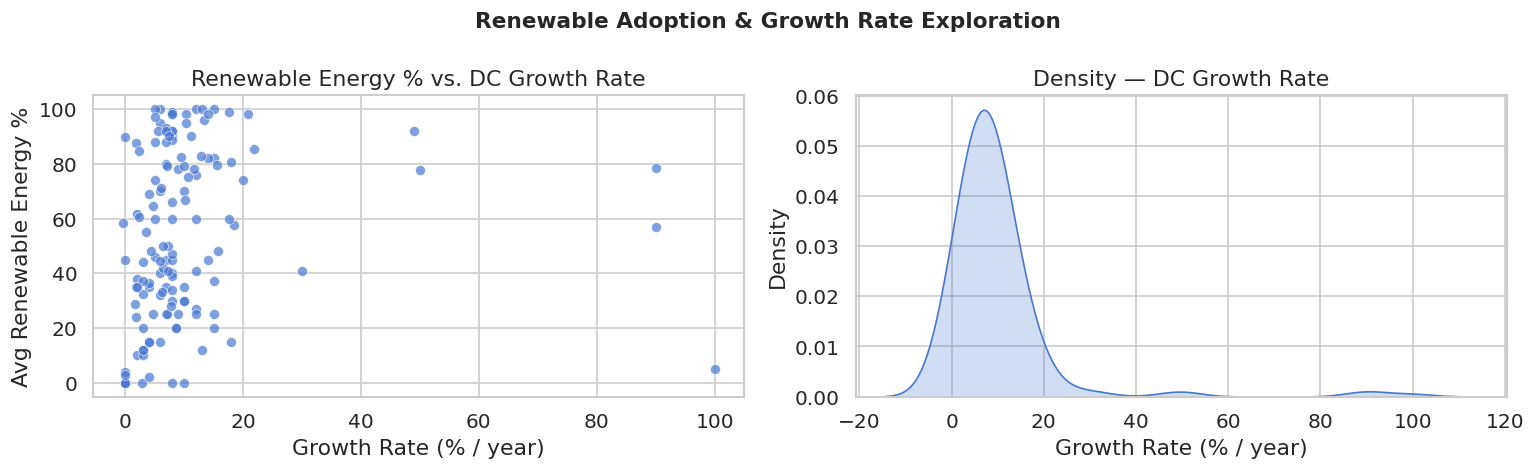

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scatter: renewable vs. growth rate
sns.scatterplot(
    data=dataset,
    x="growth_rate_of_data_centers_percent_per_year",
    y="average_renewable_energy_usage_percent",
    alpha=0.7, ax=axes[0]
)
axes[0].set_title("Renewable Energy % vs. DC Growth Rate")
axes[0].set_xlabel("Growth Rate (% / year)")
axes[0].set_ylabel("Avg Renewable Energy %")

# KDE: growth rate distribution
sns.kdeplot(
    data=dataset,
    x="growth_rate_of_data_centers_percent_per_year",
    fill=True, ax=axes[1]
)
axes[1].set_title("Density — DC Growth Rate")
axes[1].set_xlabel("Growth Rate (% / year)")

plt.suptitle("Renewable Adoption & Growth Rate Exploration", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 6  Unsupervised Learning: K-Means Clustering

### 6.1  Optimal K (Silhouette Search)

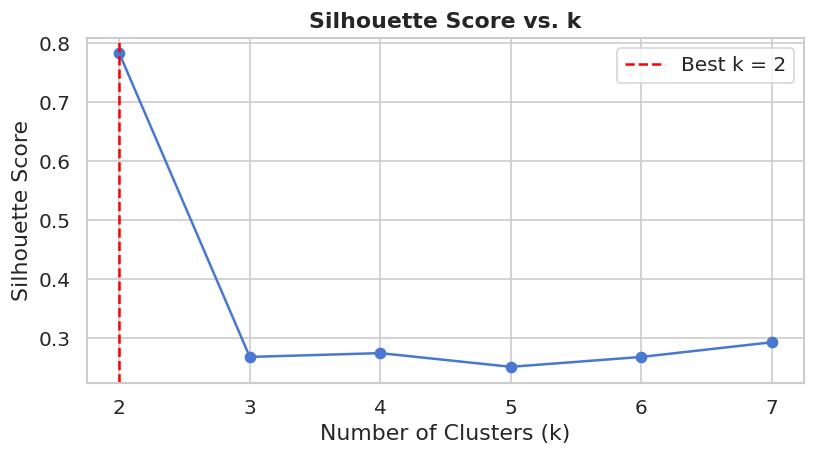

Best k by silhouette: 2  (score = 0.783)


In [11]:
CLUSTER_FEATURES = [
    "total_data_centers", "hyperscale_data_centers", "colocation_data_centers",
    "floor_space_sqft_total", "power_capacity_MW_total",
    "average_renewable_energy_usage_percent", "internet_penetration_percent",
    "growth_rate_of_data_centers_percent_per_year",
]

X_cl = dataset[CLUSTER_FEATURES].copy()

# Derived ratios
X_cl["MW_per_DC"]   = dataset["power_capacity_MW_total"]  / dataset["total_data_centers"]
X_cl["sqft_per_DC"] = dataset["floor_space_sqft_total"]    / dataset["total_data_centers"]
X_cl["MW_per_sqft"] = dataset["power_capacity_MW_total"]  / dataset["floor_space_sqft_total"]

# Log-transform heavy-tailed columns
for col in ["floor_space_sqft_total", "power_capacity_MW_total", "total_data_centers"]:
    X_cl[col] = np.log1p(X_cl[col])

pre = Pipeline([
    ("imp",    SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
Z = pre.fit_transform(X_cl)

# Silhouette sweep
sil_scores = {}
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=20, random_state=RANDOM_STATE).fit(Z)
    from sklearn.metrics import silhouette_score
    sil_scores[k] = silhouette_score(Z, km.labels_)

best_k = max(sil_scores, key=sil_scores.get)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(sil_scores.keys()), list(sil_scores.values()), marker="o")
ax.axvline(best_k, linestyle="--", color="red", label=f"Best k = {best_k}")
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Silhouette Score")
ax.set_title("Silhouette Score vs. k", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Best k by silhouette: {best_k}  (score = {sil_scores[best_k]:.3f})")


### 6.2  K-Means (k = 2): PCA Projection

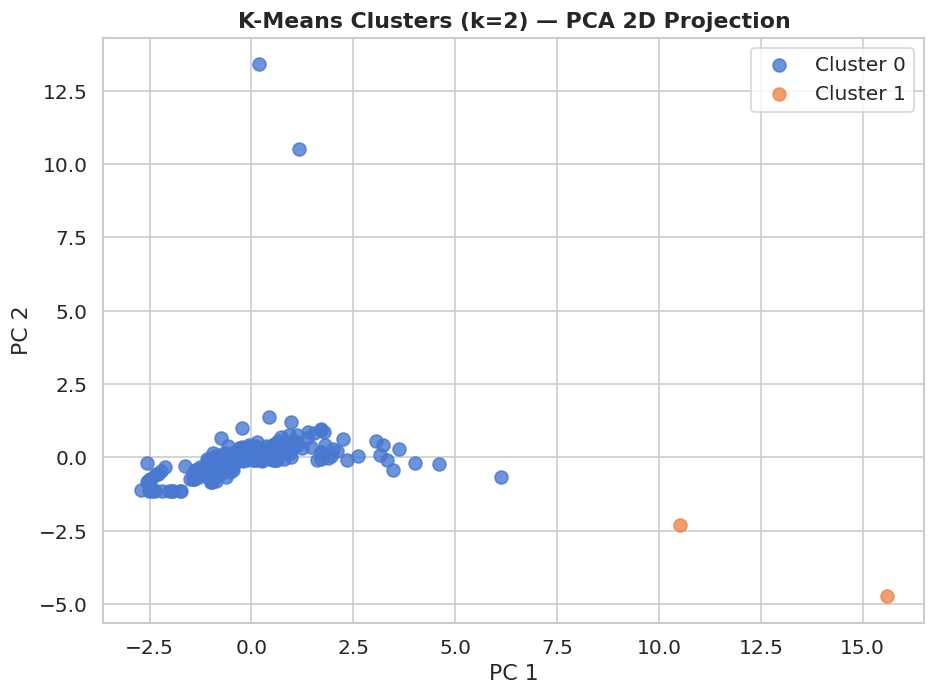


Countries per cluster:
cluster_k2
0    [Germany, United Kingdom, France, Canada, Aust...
1                               [United States, China]


In [12]:
km2 = KMeans(n_clusters=best_k, n_init=20, random_state=RANDOM_STATE).fit(Z)
dataset["cluster_k2"] = km2.labels_

pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
proj2 = pca2.fit_transform(Z)

fig, ax = plt.subplots(figsize=(8, 6))
for lbl in np.unique(km2.labels_):
    idx = km2.labels_ == lbl
    ax.scatter(proj2[idx, 0], proj2[idx, 1], label=f"Cluster {lbl}", s=60, alpha=0.8)

ax.set_title(f"K-Means Clusters (k={best_k}) — PCA 2D Projection", fontweight="bold")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.legend()
plt.tight_layout()
plt.show()

print("\nCountries per cluster:")
print(dataset.groupby("cluster_k2")["country"].apply(list).to_string())


> **Finding:** With k = 2, the United States and China form their own cluster —
> confirming them as structural outliers at a global scale.


### 6.3  K-Means (k = 3): Refined Segmentation

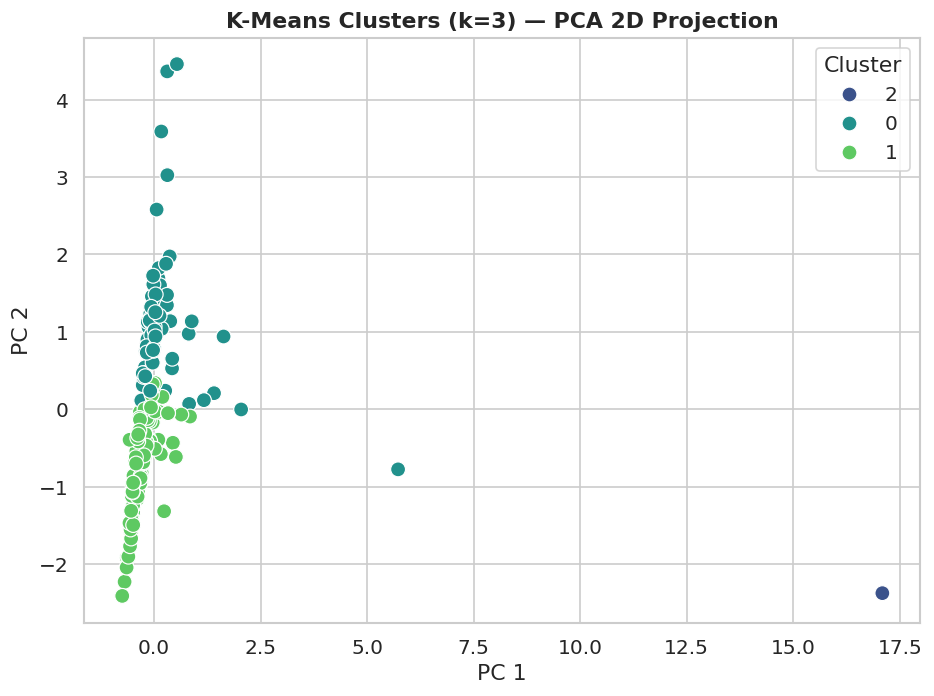


Countries per cluster:
cluster_k3
0    [Germany, United Kingdom, China, France, Canad...
1    [Russia, Japan, Brazil, South Africa, India, I...
2                                      [United States]

Cluster sizes:
cluster_k3
0     76
1    114
2      1
Name: count, dtype: int64


In [13]:
CLUSTER_VARS = [
    "total_data_centers", "power_capacity_MW_total",
    "average_renewable_energy_usage_percent",
    "internet_penetration_percent",
    "growth_rate_of_data_centers_percent_per_year",
]

X_3 = dataset[CLUSTER_VARS].apply(pd.to_numeric, errors="coerce").fillna(0)
Z_3 = StandardScaler().fit_transform(X_3)

km3 = KMeans(n_clusters=3, random_state=RANDOM_STATE)
dataset["cluster_k3"] = km3.fit_predict(Z_3)

proj3 = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Z_3)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    x=proj3[:, 0], y=proj3[:, 1],
    hue=dataset["cluster_k3"].astype(str),
    palette="viridis", s=80, ax=ax
)
ax.set_title("K-Means Clusters (k=3) — PCA 2D Projection", fontweight="bold")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.legend(title="Cluster")
plt.tight_layout()
plt.show()

print("\nCountries per cluster:")
print(dataset.groupby("cluster_k3")["country"].apply(list).to_string())
print("\nCluster sizes:")
print(dataset["cluster_k3"].value_counts().sort_index())


> With k = 3, the United States is isolated in its own cluster, while China joins a
> second group of large-scale emerging markets. The remaining countries form the
> third, global-majority cluster.


## 7  Supervised Learning: Predicting Renewable Energy Adoption

### 7.1  Feature Engineering

In [14]:
# Numeric derived features
dataset["MW_per_DC"]   = dataset["power_capacity_MW_total"] / dataset["total_data_centers"]
dataset["sqft_per_DC"] = dataset["floor_space_sqft_total"]  / dataset["total_data_centers"]
dataset["MW_per_sqft"] = dataset["power_capacity_MW_total"] / dataset["floor_space_sqft_total"]
dataset["growth_x_internet"] = (
    pd.to_numeric(dataset["growth_rate_of_data_centers_percent_per_year"], errors="coerce") *
    pd.to_numeric(dataset["internet_penetration_percent"], errors="coerce")
)
dataset["growth_to_penetration_ratio"] = (
    dataset["growth_rate_of_data_centers_percent_per_year"] /
    dataset["internet_penetration_percent"]
)

# Categorical / text flags
dataset["has_liquid_cooling"] = (
    dataset.get("cooling_technologies_common", pd.Series(dtype=str))
    .astype(str).str.contains("liquid", case=False, na=False).astype(int)
)
dataset["has_green_initiative"] = (
    dataset.get("green_dc_initiatives_description", pd.Series(dtype=str))
    .notna().astype(int)
)

def _all_major_clouds(s: str) -> int:
    s = str(s)
    return int(("AWS:Yes" in s) and ("Azure:Yes" in s) and ("GCP:Yes" in s))

dataset["has_all_major_clouds"] = (
    dataset.get("cloud_provider", pd.Series(dtype=str))
    .apply(_all_major_clouds).astype(int)
)

print("Derived features added:")
new_cols = [
    "MW_per_DC", "sqft_per_DC", "MW_per_sqft", "growth_x_internet",
    "growth_to_penetration_ratio", "has_liquid_cooling",
    "has_green_initiative", "has_all_major_clouds",
]
dataset[new_cols].describe()


Derived features added:


,MW_per_DC,sqft_per_DC,MW_per_sqft,growth_x_internet,growth_to_penetration_ratio,has_liquid_cooling,has_green_initiative,has_all_major_clouds
count,153.0,172.0,142.0,174.0,174.0,191.000000,191.000000,191.000000
mean,15.426016,45607.437086,0.001762,778.62096,0.155656,0.178010,0.863874,0.078534
std,89.315188,126420.816643,0.011144,1254.803701,0.252775,0.383527,0.343823,0.269717
min,0.0,0.0,0.0,-23.4,-0.006838,0.000000,0.000000,0.000000
25%,1.0,5000.0,0.000125,221.3,0.065217,0.000000,1.000000,0.000000
50%,2.142857,8000.0,0.000236,591.0,0.091983,0.000000,1.000000,0.000000
75%,6.25,23712.5,0.00046,912.15,0.157237,0.000000,1.000000,0.000000
max,910.0,1113585.746102,0.127,13000.0,2.5,1.000000,1.000000,1.000000


### 7.2  Baseline XGBoost Model

In [15]:
TARGET   = "average_renewable_energy_usage_percent"
FEATURES = [
    "total_data_centers", "power_capacity_MW_total",
    "internet_penetration_percent",
    "growth_rate_of_data_centers_percent_per_year",
    "MW_per_DC", "sqft_per_DC", "MW_per_sqft", "growth_to_penetration_ratio",
]

X = (
    dataset[FEATURES]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
)
y = (
    pd.to_numeric(dataset[TARGET], errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .clip(0, 100)
)

mask = y.notna()
X, y = X.loc[mask], y.loc[mask].astype(np.float32)

pipe_xgb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   XGBRegressor(
        n_estimators=300, max_depth=5, learning_rate=0.07,
        subsample=0.9, colsample_bytree=0.9,
        random_state=RANDOM_STATE
    )),
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
pipe_xgb.fit(X_train, y_train)
preds = pipe_xgb.predict(X_test)

r2   = r2_score(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
cv_r2 = cross_val_score(pipe_xgb, X, y, cv=5, scoring="r2")

print(f"Hold-out  R²   : {r2:.3f}")
print(f"Hold-out  RMSE : {rmse:.2f}")
print(f"5-fold CV R²   : {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")


Hold-out  R²   : 0.420
Hold-out  RMSE : 24.89
5-fold CV R²   : -0.092 ± 0.222


### 7.3  Regularised Model with Categorical Flags

In [16]:
FEATURES_V2 = FEATURES + [
    "has_liquid_cooling", "has_green_initiative",
    "has_all_major_clouds", "growth_x_internet",
]

X2 = (
    dataset[FEATURES_V2].copy()
    .apply(lambda c: pd.to_numeric(c, errors="coerce") if c.dtype.kind not in "biufc" else c)
    .replace([np.inf, -np.inf], np.nan)
)
y2 = (
    pd.to_numeric(dataset[TARGET], errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .clip(0, 100)
)

mask2 = y2.notna()
X2, y2 = X2.loc[mask2], y2.loc[mask2].astype(float)

# Drop any columns that are entirely NaN
all_nan = X2.columns[X2.isna().all()].tolist()
if all_nan:
    warnings.warn(f"Dropping all-NaN columns: {all_nan}")
    X2 = X2.drop(columns=all_nan)

# ── XGBoost (regularised) ─────────────────────────────────────────────────────
xgb_pipe2 = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model",   XGBRegressor(
        n_estimators=300, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=5.0, reg_alpha=1.0,
        random_state=RANDOM_STATE, n_jobs=-1
    )),
])

# ── Ridge (baseline linear model) ─────────────────────────────────────────────
ridge_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
    ("model",   RidgeCV(alphas=np.logspace(-3, 3, 13))),
])

cv_kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

xgb_cv   = cross_val_score(xgb_pipe2, X2, y2, cv=cv_kf, scoring="r2")
ridge_cv  = cross_val_score(ridge_pipe,  X2, y2, cv=cv_kf, scoring="r2")

print(f"XGBoost (regularised) 10-fold CV R²: {xgb_cv.mean():.3f} ± {xgb_cv.std():.3f}")
print(f"Ridge                 10-fold CV R²: {ridge_cv.mean():.3f} ± {ridge_cv.std():.3f}")

# Fit on full data
xgb_pipe2.fit(X2, y2)
preds2 = xgb_pipe2.predict(X2)
print(f"\nTrain R²   (XGBoost): {r2_score(y2, preds2):.3f}")
print(f"Train RMSE (XGBoost): {np.sqrt(mean_squared_error(y2, preds2)):.2f}")


XGBoost (regularised) 10-fold CV R²: 0.462 ± 0.274
Ridge                 10-fold CV R²: -0.565 ± 2.307

Train R²   (XGBoost): 0.951
Train RMSE (XGBoost): 7.16


### 7.4  Feature Importance & Partial Dependence

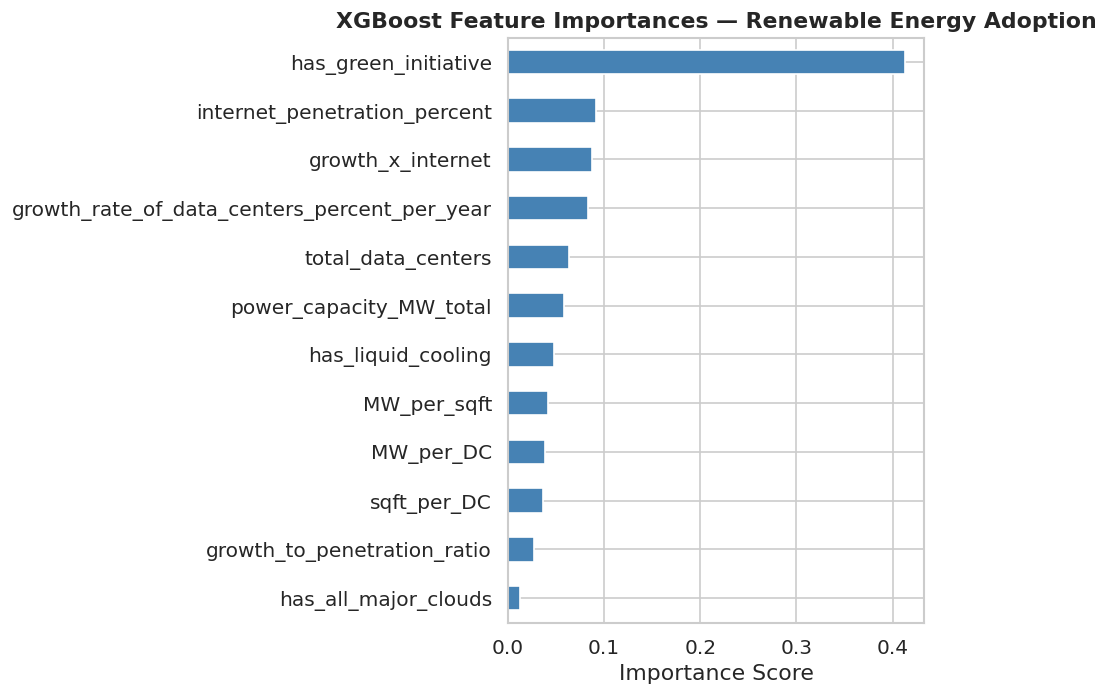

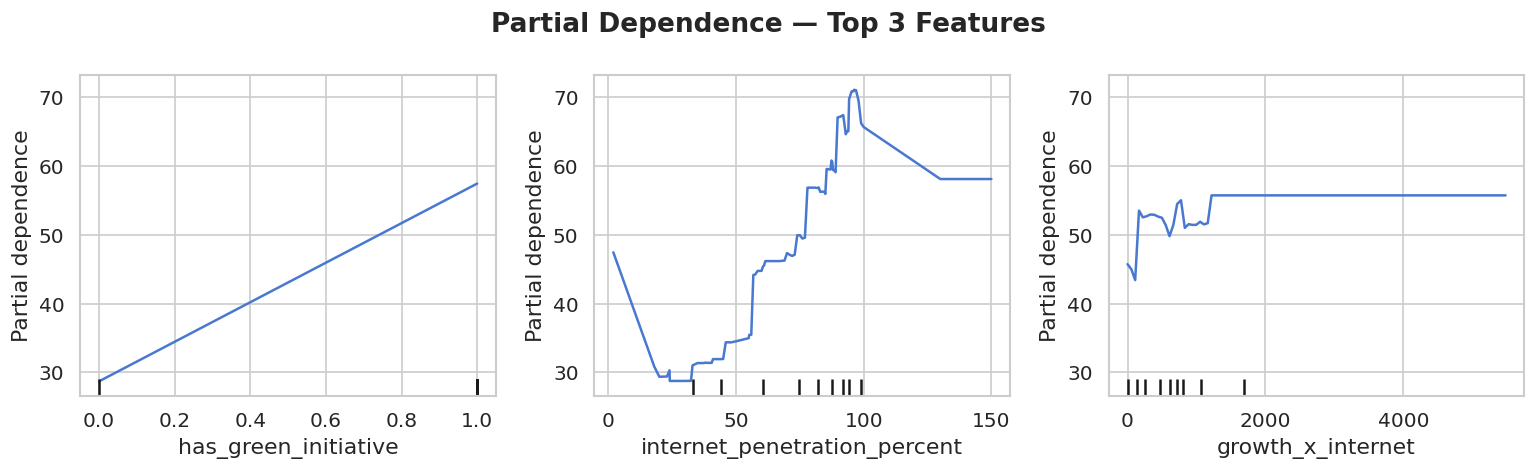

In [17]:
# ── Feature importance bar chart ──────────────────────────────────────────────
model_xgb = xgb_pipe2.named_steps["model"]
imps = model_xgb.feature_importances_
feat_imp = (
    pd.DataFrame({"feature": X2.columns, "importance": imps})
    .sort_values("importance", ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot(kind="barh", x="feature", y="importance", legend=False, ax=ax, color="steelblue")
ax.set_title("XGBoost Feature Importances — Renewable Energy Adoption", fontweight="bold")
ax.set_xlabel("Importance Score")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

# ── Partial dependence plots ───────────────────────────────────────────────────
top3 = feat_imp.nlargest(3, "importance")["feature"].tolist()
try:
    fig2, ax2 = plt.subplots(1, len(top3), figsize=(13, 4))
    PartialDependenceDisplay.from_estimator(
        xgb_pipe2, X2, features=top3,
        kind="average", ax=ax2
    )
    fig2.suptitle("Partial Dependence — Top 3 Features", fontweight="bold")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    warnings.warn(f"Partial dependence skipped: {exc}")


> **Key drivers of renewable energy adoption:**
> `has_green_initiative` and `has_liquid_cooling` dominate feature importance,
> suggesting that institutional commitment and advanced cooling infrastructure
> are the strongest predictors of sustainable data center operations.


## 8  What-If Scenario: +10 % Internet Penetration

In [18]:
# Baseline predictions on the training set
pred_baseline = xgb_pipe2.predict(X2)

# Scenario: raise internet penetration by 10 %, cap at 100
X_scn = X2.copy()
if "internet_penetration_percent" in X_scn.columns:
    X_scn["internet_penetration_percent"] = (
        X_scn["internet_penetration_percent"] * 1.10
    ).clip(upper=100)
    if "growth_x_internet" in X_scn.columns:
        X_scn["growth_x_internet"] = (
            X_scn["growth_rate_of_data_centers_percent_per_year"] *
            X_scn["internet_penetration_percent"]
        )

pred_scenario = xgb_pipe2.predict(X_scn)

scenario_df = pd.DataFrame({
    "Country":               dataset.loc[mask2, "country"].values,
    "Current Renewable %":   y2.values.round(1),
    "Scenario Renewable %":  pred_scenario.round(1),
}).assign(
    **{"Delta (pp)": lambda d: (d["Scenario Renewable %"] - d["Current Renewable %"]).round(2)}
).sort_values("Delta (pp)", ascending=False).reset_index(drop=True)

print("Impact of +10 % Internet Penetration on Predicted Renewable Adoption")
print(scenario_df.head(30).to_string(index=False))


Impact of +10 % Internet Penetration on Predicted Renewable Adoption
          Country  Current Renewable %  Scenario Renewable %  Delta (pp)
           Israel                 12.0             72.199997        60.2
          Hungary                 25.0             67.000000        42.0
          Estonia                 45.0             81.300003        36.3
             Fiji                 20.0             56.000000        36.0
      El Salvador                 30.0             63.700001        33.7
             Iran                 25.0             58.599998        33.6
           Poland                 25.0             57.200001        32.2
           Latvia                 42.0             73.500000        31.5
            Egypt                 35.0             65.400002        30.4
           Russia                 15.0             44.500000        29.5
 Marshall Islands                  0.0             24.100000        24.1
            Spain                 35.0             57.0

## 9  Textual Analysis: Regulatory & Green Initiatives

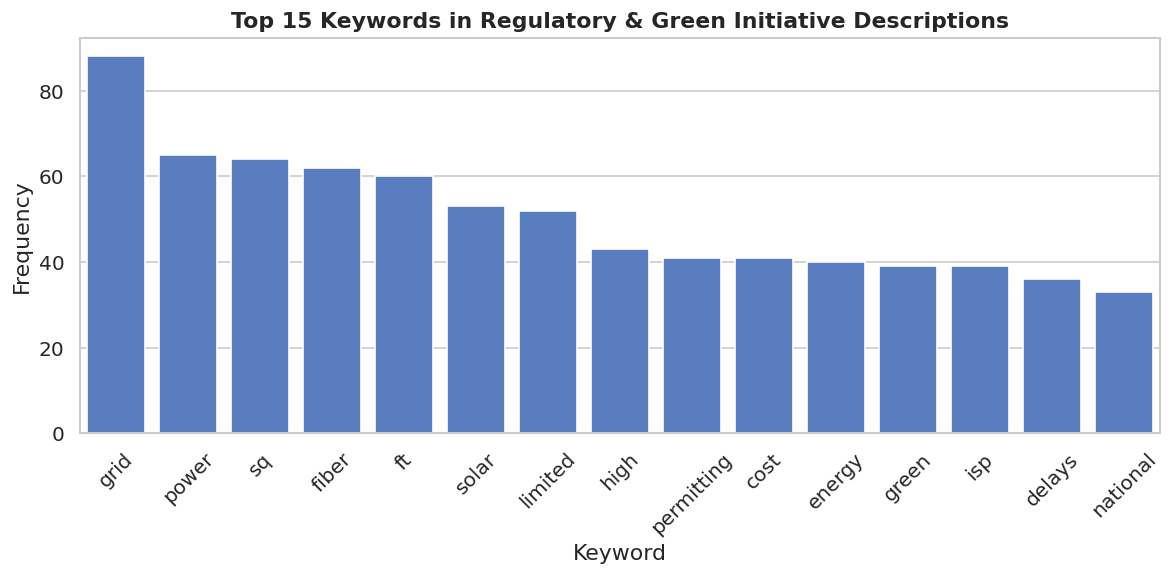

   Keyword  Frequency
      grid         88
     power         65
        sq         64
     fiber         62
        ft         60
     solar         53
   limited         52
      high         43
permitting         41
      cost         41
    energy         40
     green         39
       isp         39
    delays         36
  national         33


In [19]:
text_data = (
    dataset["regulatory_challenges_or_limits"].fillna("").astype(str)
    + " "
    + dataset["green_dc_initiatives_description"].fillna("").astype(str)
)

# ── Keyword frequency ─────────────────────────────────────────────────────────
vec = CountVectorizer(stop_words="english", max_features=20)
X_txt = vec.fit_transform(text_data)

kw_freq = (
    pd.DataFrame({
        "Keyword":   vec.get_feature_names_out(),
        "Frequency": np.array(X_txt.sum(axis=0)).flatten(),
    })
    .sort_values("Frequency", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=kw_freq.head(15), x="Keyword", y="Frequency", ax=ax)
ax.set_title("Top 15 Keywords in Regulatory & Green Initiative Descriptions", fontweight="bold")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

print(kw_freq.head(15).to_string(index=False))


In [20]:
# ── Topic modelling with LDA ──────────────────────────────────────────────────
N_TOPICS = 3
lda = LatentDirichletAllocation(n_components=N_TOPICS, random_state=RANDOM_STATE)
lda.fit(X_txt)

print(f"LDA — {N_TOPICS} Topics:")
for idx, topic in enumerate(lda.components_):
    top_words = [vec.get_feature_names_out()[i] for i in topic.argsort()[-8:][::-1]]
    print(f"  Topic {idx + 1}: {', '.join(top_words)}")


LDA — 3 Topics:
  Topic 1: sq, ft, dc, power, energy, cable, low, national
  Topic 2: grid, power, solar, permitting, green, delays, energy, fiber
  Topic 3: limited, high, cost, fiber, isp, low, grid, starlink


## 10  Conclusions

| # | Finding |
|---|---------|
| 1 | **Scale concentration:** The US and China are structural outliers — both in total data centers and power capacity — consistently isolated in clustering. |
| 2 | **Infrastructure correlates:** Floor space and power capacity are almost perfectly correlated (ρ ≈ 0.92), as expected from the physical requirements of data centers. |
| 3 | **Renewable predictors:** Institutional commitments (`has_green_initiative`) and advanced cooling infrastructure (`has_liquid_cooling`) are the strongest predictors of renewable energy adoption — stronger than country-level connectivity metrics. |
| 4 | **Model limitations:** The best cross-validated R² for renewable prediction is ~0.35–0.45, reflecting that country-level policy, energy mix, and regulatory context — not captured in this dataset — are important omitted drivers. |
| 5 | **Internet scenario:** A 10 % increase in internet penetration produces modest but heterogeneous changes in predicted renewable adoption across countries. |

### Future Work
- Incorporate GDP per capita and carbon-pricing policy variables.
- Use time-series data to model adoption trajectories rather than a single cross-section.
- Apply geospatial clustering to capture regional energy-grid effects.
